### Data analyzing 
**Data understanding**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
countries = pd.read_csv('global_fuel_prices_2020_2026.csv')
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


*Data exploration*

In [110]:
# 
print(f'Regions: {countries.region.nunique()} \nCountries: {countries.country.nunique()}')
print('-'*20)
#The coutries for a region
region_country= countries.groupby(['region', 'income_level'])['country'].nunique().to_frame()
region_country


Regions: 7 
Countries: 84
--------------------


country
region        income_level         
Africa        Low                17
              Middle              6
Asia          High                5
              Low                 5
              Middle              7
Europe        High               17
              Middle              6
Middle East   High                5
              Middle              4
North America High                2
              Middle              1
Oceania       High                2
South America High                1
              Low                 1
              Middle              5

In [118]:
#highest countries in fuel prices 
prices_for_countries = countries.groupby(['country', 'income_level'])[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter', 'tax_percentage']].mean().round(2).sort_values(by= 'petrol_usd_liter',ascending=False).reset_index()
print("Highest countries fuel prices")
prices_for_countries[:11]

Highest countries fuel prices


,country,income_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,tax_percentage
0,Hong Kong,High,5.54,5.10,4.16,37.00
1,Norway,High,4.76,4.43,3.57,36.24
2,Netherlands,High,4.66,4.32,3.49,37.80
3,Ireland,High,4.65,4.55,3.49,38.71
4,Denmark,High,4.54,4.32,3.41,38.87
5,Singapore,High,4.54,4.21,3.41,38.18
6,Sweden,High,4.43,4.10,3.32,37.00
7,Switzerland,High,4.39,4.17,3.29,37.93
8,Belgium,High,4.32,4.21,3.24,37.92
9,Finland,High,4.26,4.17,3.19,36.64


In [119]:
print("Lowest Countries fuel prices")
prices_for_countries.tail(10)

Lowest Countries fuel prices


,country,income_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,tax_percentage
74,Saudi Arabia,High,0.25,0.22,0.19,15.36
75,Qatar,High,0.23,0.21,0.18,13.94
76,Nigeria,Low,0.21,0.19,0.16,14.30
77,Kuwait,High,0.19,0.18,0.15,15.32
78,Egypt,Low,0.17,0.16,0.13,15.39
79,Iraq,Middle,0.16,0.14,0.12,15.10
80,Algeria,Middle,0.14,0.12,0.11,15.18
81,Libya,Low,0.06,0.05,0.04,15.28
82,Iran,Middle,0.04,0.03,0.03,13.90
83,Venezuela,Low,0.02,0.02,0.02,15.04


In [121]:
countries.describe()

,date,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,year
count,27468,27468.000000,27468.000000,27468.000000,27468.000000,27468.000000,27468.000000
mean,2023-02-20 00:00:00.000000256,2.281915,2.133760,1.711473,106.686453,26.774468,2022.654434
min,2020-01-06 00:00:00,0.010000,0.010000,0.010000,47.970000,0.000000,2020.000000
25%,2021-07-26 00:00:00,0.926000,0.858000,0.695000,101.140000,13.500000,2021.000000
50%,2023-02-20 00:00:00,2.116500,1.954500,1.588000,112.270000,23.400000,2023.000000
75%,2024-09-16 00:00:00,3.457000,3.231000,2.590000,119.410000,38.900000,2024.000000
max,2026-04-06 00:00:00,6.779000,6.240000,5.100000,130.000000,65.000000,2026.000000
std,NaN,1.540612,1.465058,1.155543,18.972391,17.203349,1.813971


In [31]:
subsidy_level_pers = countries.groupby('subsidy_level')['tax_percentage'].mean().round(2).sort_values().to_frame()
subsidy_level_pers


,tax_percentage
subsidy_level,
Medium,14.85
Very High,14.88
High,15.07
Low,37.55


               country
subsidy_level         
High                12
Low                 44
Medium              18
Very High           10


array([<Axes: >], dtype=object)

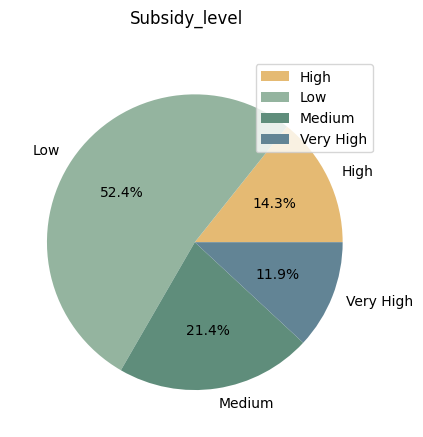

In [3]:
# Country income level & subside level and  the persantage of subsidy level
subsidy_level = countries.groupby('subsidy_level')['country'].nunique().to_frame()
print(f'{subsidy_level}')
mcolors = [ '#E5BA73', '#94B49F', '#5F8D7B', '#628495']

subsidy_level.plot(kind= 'pie', autopct = '%1.1f%%',title = "Subsidy_level", ylabel = '', colors =mcolors,subplots= True)

Text(0, 0.5, 'USD per litre')

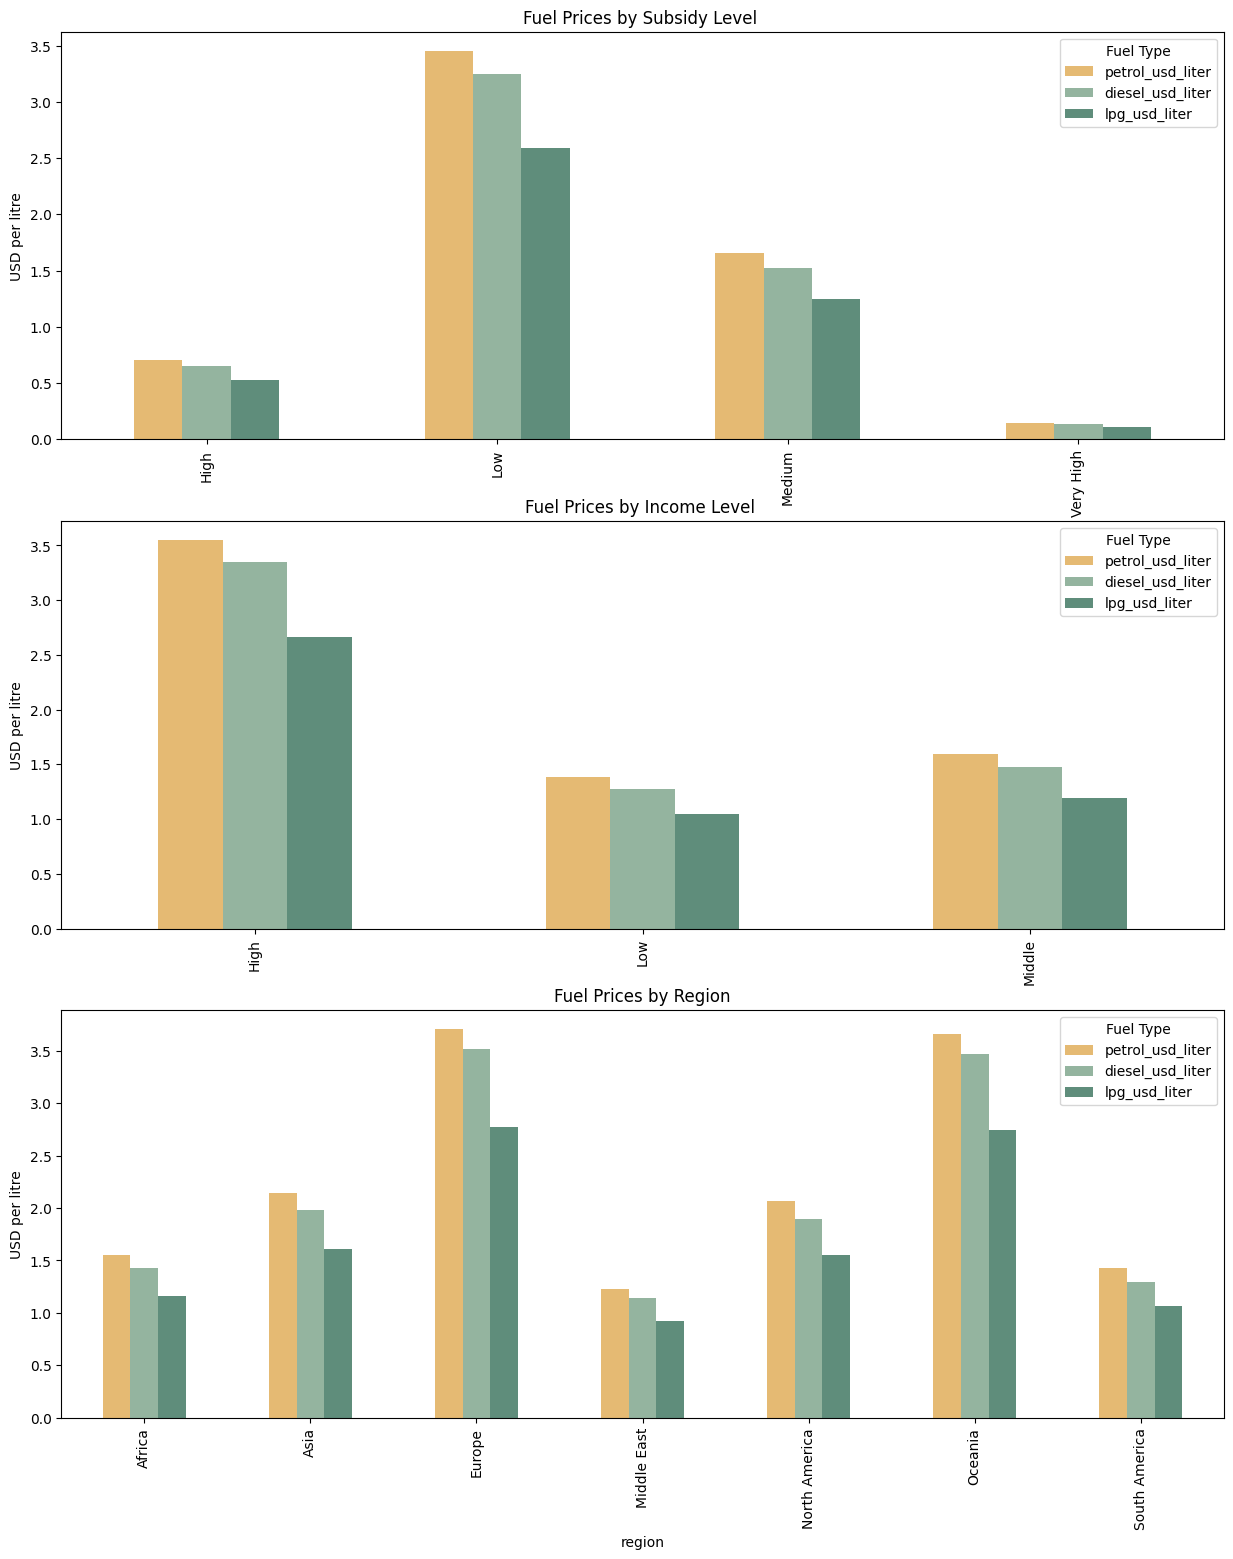

In [129]:
# Find the averge prices of subsidy level in different countries 
aver_region_prices = countries.groupby('region')[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']].mean()

averge_subsidy_prices =  countries.groupby('subsidy_level')[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']].mean()

aver_income_prices = countries.groupby('income_level')[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']].mean()

fuels_types = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']

fig, axes = plt.subplots( nrows=3, figsize = (15,18))
axes= axes.flatten()

averge_subsidy_prices.plot(kind= 'bar', color= mcolors, ax=axes[0] )
axes[0].legend(title='Fuel Type')
axes[0].set_title('Fuel Prices by Subsidy Level ')
axes[0].set_ylabel("USD per litre")

aver_income_prices.plot(kind= 'bar', color= mcolors, ax=axes[1] )
axes[1].legend(title='Fuel Type')
axes[1].set_title('Fuel Prices by Income Level ')
axes[1].set_ylabel("USD per litre")
axes[1].set_xlabel('')

aver_region_prices.plot(kind= 'bar',color= mcolors, ax=axes[2] )
axes[2].legend(title='Fuel Type')
axes[2].set_title('Fuel Prices by Region')
axes[2].set_ylabel("USD per litre")




<function matplotlib.pyplot.show(close=None, block=None)>

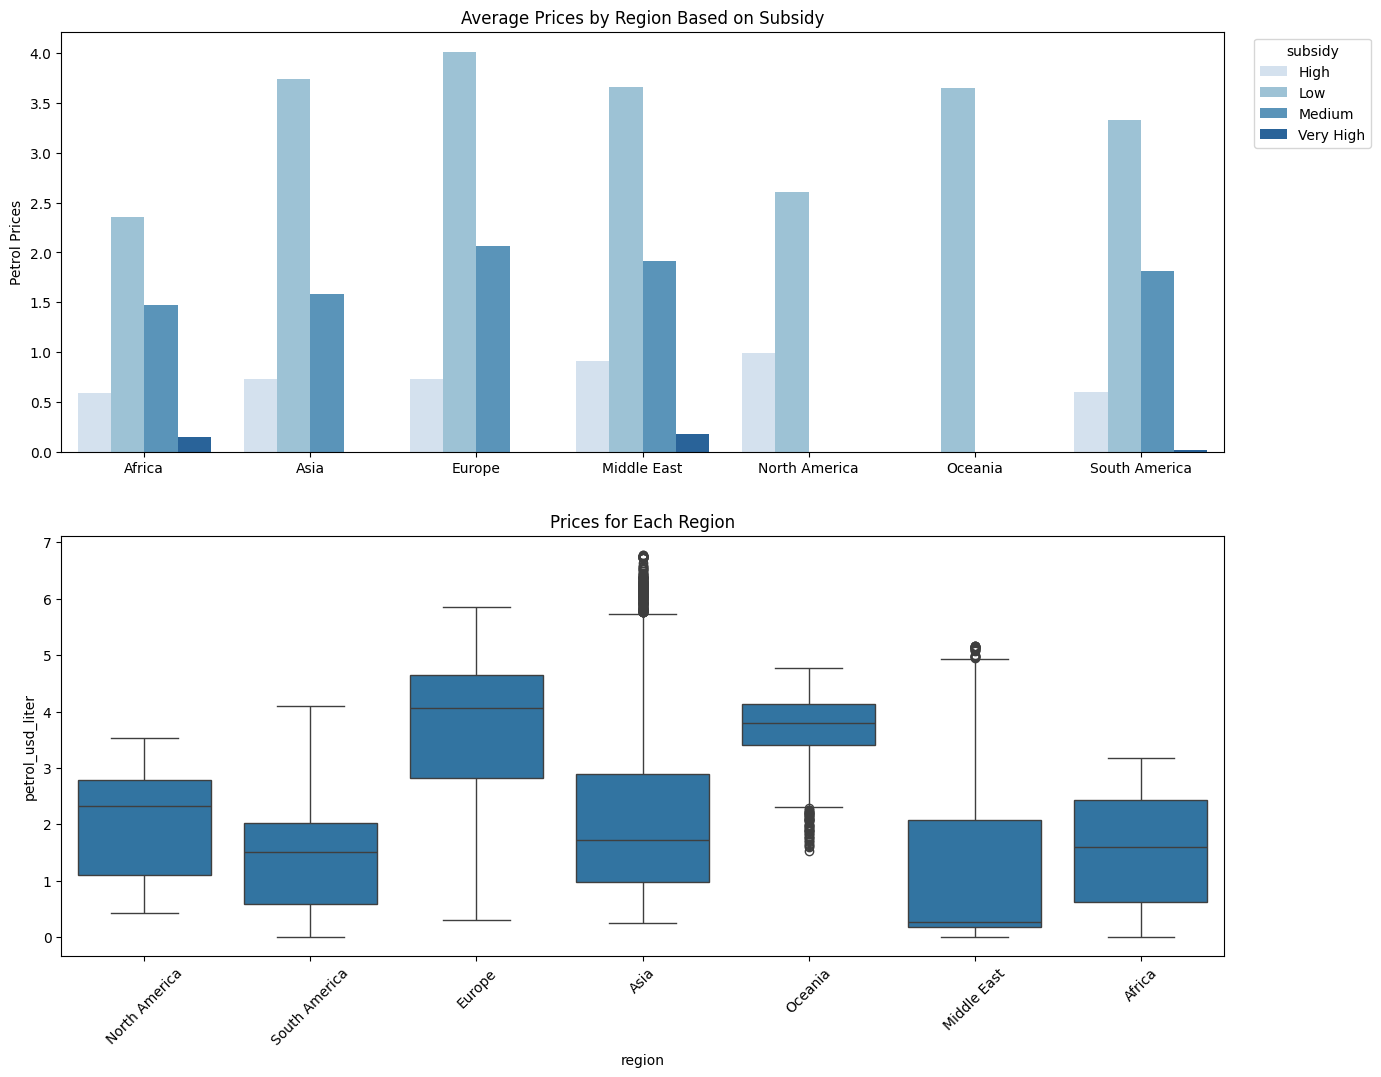

In [27]:
#Find the average prices of regions based on subsidy level
country_income_vs_prices = countries.groupby(['region', 'subsidy_level'])['petrol_usd_liter'].mean().to_frame()

#The prices for each region 
# region_prices = countries.groupby('region')['petrol_usd_liter'].mean().to_frame()
#---------------------------

fig, axes = plt.subplots(nrows=2, figsize= (15,12))

sns.barplot(data= country_income_vs_prices, x='region', y='petrol_usd_liter', palette = 'Blues', hue=  'subsidy_level', ax= axes[0])

axes[0].tick_params(axis="x", rotation= 0) 
axes[0].legend(title= 'subsidy', loc= 'upper left', bbox_to_anchor=(1.02, 1))
axes[0].set_title("Average Prices by Region Based on Subsidy")
axes[0].set_xlabel('')
axes[0].set_ylabel('Petrol Prices')
#----------------------------------------------------

sns.boxplot(data = countries,x= 'region', y= 'petrol_usd_liter',ax=axes[1] )
axes[1].tick_params(axis= 'x', rotation= 45)
axes[1].set_title("Prices for Each Region")


plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

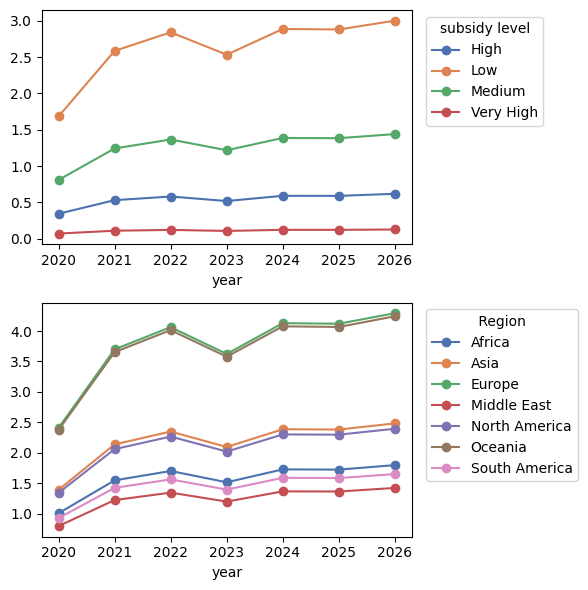

In [125]:
#Track the prices of subsidies & countries throughout the years
# Return a date type 
a_color = sns.color_palette('deep', 7)
countries.date = pd.to_datetime(countries.date, errors= 'coerce')
countries['year'] = countries.date.dt.year
#Get the data
tracking_subsidy = countries.groupby(['year', 'subsidy_level'])['lpg_usd_liter'].mean().unstack()
tracking_region = countries.groupby([ 'year','region'])['petrol_usd_liter'].mean().unstack()

#Build the charts
fig, axes = plt.subplots(nrows=2, figsize =(6,6))

tracking_subsidy .plot(marker = 'o', color = a_color, ax = axes[0])

tracking_region.plot(marker= 'o', color = a_color, ax =axes[1])
axes[0].legend(title= 'subsidy level', bbox_to_anchor=(1.02, 1), loc= 'upper left')
axes[1].legend(title= ' Region ', bbox_to_anchor=(1.02, 1), loc= 'upper left')
plt.tight_layout()
plt.show